In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

#### Importing the dataset stored by gathering the data from files in .csv format

In [2]:
df=pd.read_csv("./Tests/FallSimulation.csv", dtype={"Height": str, "Weight": str, "Test": str})

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9493571 entries, 0 to 9493570
Data columns (total 32 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Counter          int64  
 1   Temperature      float64
 2   VelInc_X         float64
 3   VelInc_Y         float64
 4   VelInc_Z         float64
 5   OriInc_w         float64
 6   OriInc_x         float64
 7   OriInc_y         float64
 8   OriInc_z         float64
 9   Acc_X            float64
 10  Acc_Y            float64
 11  Acc_Z            float64
 12  Gyr_X            float64
 13  Gyr_Y            float64
 14  Gyr_Z            float64
 15  Mag_X            float64
 16  Mag_Y            float64
 17  Mag_Z            float64
 18  Pressure         float64
 19  Roll             float64
 20  Pitch            float64
 21  Yaw              float64
 22  RSSI             float64
 23  Gender           object 
 24  Age              int64  
 25  Height           object 
 26  Weight           object 
 27  Volunteer   

## Data Preprocessing

In [4]:
df.head(10)

,Counter,Temperature,VelInc_X,VelInc_Y,VelInc_Z,OriInc_w,OriInc_x,OriInc_y,OriInc_z,Acc_X,...,RSSI,Gender,Age,Height,Weight,Volunteer,Test,Sensor,Activity Type,Activity Number
0,0,0.001160,-0.373230,-0.121765,0.999999,0.000031,0.000516,0.000637,0.028992,-9.330750,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
1,0,0.001115,-0.373789,-0.122840,0.999999,0.000232,0.000402,0.000549,0.027871,-9.344721,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
2,0,0.000427,-0.373657,-0.121826,0.999999,0.000496,0.000478,0.000340,0.010681,-9.341431,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
3,0,-0.001422,-0.374447,-0.119565,0.999999,0.000605,0.000301,0.000519,-0.035548,-9.361172,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
4,0,-0.000427,-0.373535,-0.118042,0.999999,0.000526,0.000348,0.000519,-0.010681,-9.338379,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
5,0,-0.003294,-0.371705,-0.118875,0.999999,0.000182,0.000259,0.000438,-0.082350,-9.292626,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
6,0,-0.002686,-0.371155,-0.120178,0.999999,-0.000053,0.000234,0.000206,-0.067139,-9.278870,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
7,0,-0.004126,-0.374436,-0.122784,0.999999,-0.000143,0.000153,0.000133,-0.103140,-9.360909,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
8,0,-0.005005,-0.374817,-0.124634,0.999999,0.000572,-0.000106,0.000042,-0.125122,-9.370422,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801
9,0,-0.001218,-0.372152,-0.124208,0.999999,0.000880,-0.000219,-0.000420,-0.030446,-9.303808,...,NaN,Male,27,176,67,104,1,Right Ankle Sensor,Daily activities,801


In [5]:
df.Counter.unique()

array([0])

#### Removing the Counter column as it does not serve and purpose.

In [6]:
df.drop('Counter', axis=1,inplace=True)

#### Checking to remove the 'NA' and null values in the dataset.

In [7]:
df.isna().sum()

Temperature           7601
VelInc_X              7601
VelInc_Y              7601
VelInc_Z              7601
OriInc_w              7601
OriInc_x              7601
OriInc_y              7601
OriInc_z              7601
Acc_X                 7601
Acc_Y                 7601
Acc_Z                 7601
Gyr_X                 7601
Gyr_Y                 7601
Gyr_Z                 7601
Mag_X                 7601
Mag_Y                 7601
Mag_Z                    0
Pressure             12349
Roll                 12349
Pitch                12349
Yaw                      0
RSSI               9493571
Gender                   0
Age                      0
Height                   0
Weight                   0
Volunteer                0
Test                     0
Sensor                   0
Activity Type            0
Activity Number          0
dtype: int64

#### Dropping the 'RSSI' column as a substantial amount of 'NA' values are present in the column.

In [8]:
df.drop('RSSI', axis=1, inplace=True)

#### Dropping the rows for the below as there are only a small amount of values missing as compared to the dataset

In [9]:
df.dropna(subset=['Temperature','VelInc_X','VelInc_Y','VelInc_Z','OriInc_w','OriInc_x',
                 'OriInc_y','OriInc_z','Acc_X','Acc_Y','Acc_Z','Gyr_X','Gyr_Y','Gyr_Z',
                 'Mag_X','Mag_Y'], inplace=True)

#### Dropping the rows for Pressure,Roll and Pitch as the values missing are only 4748

In [10]:
df.dropna(subset=['Pressure','Roll','Pitch'], inplace=True)

In [11]:
df.isna().values.any()

False

In [12]:
df.isnull().values.any()

False

In [13]:
df.isna().sum()

Temperature        0
VelInc_X           0
VelInc_Y           0
VelInc_Z           0
OriInc_w           0
OriInc_x           0
OriInc_y           0
OriInc_z           0
Acc_X              0
Acc_Y              0
Acc_Z              0
Gyr_X              0
Gyr_Y              0
Gyr_Z              0
Mag_X              0
Mag_Y              0
Mag_Z              0
Pressure           0
Roll               0
Pitch              0
Yaw                0
Gender             0
Age                0
Height             0
Weight             0
Volunteer          0
Test               0
Sensor             0
Activity Type      0
Activity Number    0
dtype: int64

#### The Temperature column has no relevance to this study hence excluding it from the dataset as it is causing the distribution to be skewed.

In [14]:
df.drop('Temperature',axis=1,inplace=True)

#### Changing the dtypes from object to numeric and categorical respectively.

In [15]:
df['Height'] = df['Height'].str.replace('cm', '').astype(float)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Test'] = pd.to_numeric(df['Test'], errors='coerce')
print(df.dtypes)

VelInc_X           float64
VelInc_Y           float64
VelInc_Z           float64
OriInc_w           float64
OriInc_x           float64
OriInc_y           float64
OriInc_z           float64
Acc_X              float64
Acc_Y              float64
Acc_Z              float64
Gyr_X              float64
Gyr_Y              float64
Gyr_Z              float64
Mag_X              float64
Mag_Y              float64
Mag_Z              float64
Pressure           float64
Roll               float64
Pitch              float64
Yaw                float64
Gender              object
Age                  int64
Height             float64
Weight             float64
Volunteer            int64
Test               float64
Sensor              object
Activity Type       object
Activity Number      int64
dtype: object


In [16]:
df['Gender'] = df['Gender'].astype('category')
df['Sensor'] = df['Sensor'].astype('category')
df['Activity Type'] = df['Activity Type'].astype('category')
df['Activity Number'] = df['Activity Number'].astype('category')
print(df.dtypes)

VelInc_X            float64
VelInc_Y            float64
VelInc_Z            float64
OriInc_w            float64
OriInc_x            float64
OriInc_y            float64
OriInc_z            float64
Acc_X               float64
Acc_Y               float64
Acc_Z               float64
Gyr_X               float64
Gyr_Y               float64
Gyr_Z               float64
Mag_X               float64
Mag_Y               float64
Mag_Z               float64
Pressure            float64
Roll                float64
Pitch               float64
Yaw                 float64
Gender             category
Age                   int64
Height              float64
Weight              float64
Volunteer             int64
Test                float64
Sensor             category
Activity Type      category
Activity Number    category
dtype: object


In [17]:
df['Activity Number Encoded'] = df['Activity Number'].cat.codes

In [18]:
df.shape

(9481222, 30)

In [19]:
df['Activity Number Encoded'] = df['Activity Number Encoded'].astype('category')

## Feature Scaling:

In [20]:
X = df.iloc[:,:-10]
X

,VelInc_X,VelInc_Y,VelInc_Z,OriInc_w,OriInc_x,OriInc_y,OriInc_z,Acc_X,Acc_Y,Acc_Z,Gyr_X,Gyr_Y,Gyr_Z,Mag_X,Mag_Y,Mag_Z,Pressure,Roll,Pitch,Yaw
0,-0.373230,-0.121765,0.999999,0.000031,0.000516,0.000637,0.028992,-9.330750,-3.044128,0.001526,0.025797,0.031853,-0.558350,0.601074,0.041504,895.50,-109.270415,-0.536381,142.750864,-75.0
1,-0.373789,-0.122840,0.999999,0.000232,0.000402,0.000549,0.027871,-9.344721,-3.070998,0.011587,0.020123,0.027466,-0.555908,0.603516,0.041260,895.38,-109.250147,-0.492075,142.689290,-75.0
2,-0.373657,-0.121826,0.999999,0.000496,0.000478,0.000340,0.010681,-9.341431,-3.045654,0.024796,0.023890,0.016975,-0.555664,0.603516,0.038330,895.44,-109.199481,-0.473225,142.627486,-75.0
3,-0.374447,-0.119565,0.999999,0.000605,0.000301,0.000519,-0.035548,-9.361172,-2.989125,0.030231,0.015068,0.025940,-0.558350,0.603516,0.038574,895.50,-109.136297,-0.428186,142.578098,-76.0
4,-0.373535,-0.118042,0.999999,0.000526,0.000348,0.000519,-0.010681,-9.338379,-2.951050,0.026321,0.017405,0.025940,-0.555908,0.603516,0.043945,895.50,-109.081875,-0.384793,142.523727,-76.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9493565,-0.038147,-0.049622,0.999999,0.000095,-0.000056,0.000275,9.686279,-0.953674,-1.240540,0.004768,-0.002813,0.013733,-0.864014,0.375732,-0.790527,892.82,-139.818211,-80.573581,103.223365,-50.0
9493566,-0.038797,-0.048865,0.999999,0.000076,0.000000,0.000335,9.687114,-0.969934,-1.221633,0.003815,0.000000,0.016737,-0.863770,0.373535,-0.792969,892.84,-139.711690,-80.577357,103.121798,-50.0
9493567,-0.038818,-0.048462,0.999999,0.000111,-0.000102,0.000187,9.681702,-0.970459,-1.211548,0.005531,-0.005102,0.009346,-0.864014,0.378174,-0.793457,892.88,-139.724561,-80.583125,103.138433,-50.0
9493568,-0.038486,-0.049754,0.999999,0.000031,-0.000015,0.000239,9.690237,-0.962162,-1.243854,0.001574,-0.000763,0.011969,-0.864014,0.375732,-0.793213,892.76,-139.680017,-80.592565,103.091479,-50.0


#### Using Standard Scalar for feature scaling

In [21]:
scaler = StandardScaler()
scaler.fit(X)
X_new = scaler.transform(X)
print(X_new)
print("mean", np.mean(X, axis=0))
print("std", np.std(X, axis=0))

[[-1.57681234 -0.86110674  0.15761314 ...  1.19757914  1.42188451
  -0.81028057]
 [-1.57956647 -0.86702376  0.15761314 ...  1.19873137  1.42128789
  -0.81028057]
 [-1.57891789 -0.86144275  0.15761314 ...  1.19922159  1.42068905
  -0.81028057]
 ...
 [ 0.07122741 -0.45755233  0.15761314 ... -0.88414086  1.03806458
   1.70632786]
 [ 0.07286296 -0.4646664   0.15761314 ... -0.88438638  1.03760962
   1.70632786]
 [ 0.06912186 -0.46024045  0.15761314 ... -0.88461051  1.03812396
   1.70632786]]
mean VelInc_X     -0.053271
VelInc_Y      0.034650
VelInc_Z      0.999869
OriInc_w      0.000145
OriInc_x     -0.000018
OriInc_y      0.000178
OriInc_z      5.922468
Acc_X        -1.331061
Acc_Y         0.866611
Acc_Z         0.007242
Gyr_X        -0.000888
Gyr_Y         0.008949
Gyr_Z        -0.419133
Mag_X         0.057812
Mag_Y         0.022206
Mag_Z       889.841149
Pressure    -14.455560
Roll        -46.585951
Pitch        -3.995819
Yaw         -66.950669
dtype: float64
std VelInc_X      0.202915
V

#### Using an Ordinal Encoder for the categorical variables

In [22]:
Y = df.iloc[:, -4:-2]
Y

,Sensor,Activity Type
0,Right Ankle Sensor,Daily activities
1,Right Ankle Sensor,Daily activities
2,Right Ankle Sensor,Daily activities
3,Right Ankle Sensor,Daily activities
4,Right Ankle Sensor,Daily activities
...,...,...
9493565,Head Sensor,Daily activities
9493566,Head Sensor,Daily activities
9493567,Head Sensor,Daily activities
9493568,Head Sensor,Daily activities


In [23]:
encoder = OrdinalEncoder()
Y_new = encoder.fit_transform(Y)
print(Y_new)


[[2. 0.]
 [2. 0.]
 [2. 0.]
 ...
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [24]:
Z = df.iloc[:, -2:-1]
Z

,Activity Number
0,801
1,801
2,801
3,801
4,801
...,...
9493565,802
9493566,802
9493567,802
9493568,802


In [25]:
X_new = pd.DataFrame(X_new, columns=['VelInc_X', 'VelInc_Y', 'VelInc_Z', 'OriInc_w', 'OriInc_x', 'OriInc_y',
       'OriInc_z', 'Acc_X', 'Acc_Y', 'Acc_Z', 'Gyr_X', 'Gyr_Y', 'Gyr_Z',
       'Mag_X', 'Mag_Y', 'Mag_Z', 'Pressure', 'Roll', 'Pitch', 'Yaw'])
Y_new = pd.DataFrame(Y_new, columns=['Sensor','Activity Type'])

In [26]:
df_final= pd.concat([X_new,Y_new], axis=1)

In [27]:
df_final

,VelInc_X,VelInc_Y,VelInc_Z,OriInc_w,OriInc_x,OriInc_y,OriInc_z,Acc_X,Acc_Y,Acc_Z,...,Gyr_Z,Mag_X,Mag_Y,Mag_Z,Pressure,Roll,Pitch,Yaw,Sensor,Activity Type
0,-1.576812,-0.861107,0.157613,-0.012624,0.070376,0.041586,-1.130151,-1.602337,-0.870514,-0.012624,...,-0.222194,0.545317,0.027987,0.951742,-1.003680,1.197579,1.421885,-0.810281,2.0,0.0
1,-1.579566,-0.867024,0.157613,0.009643,0.055411,0.033629,-1.130366,-1.605135,-0.876495,0.009597,...,-0.218298,0.547768,0.027633,0.931559,-1.003465,1.198731,1.421288,-0.810281,2.0,0.0
2,-1.578918,-0.861443,0.157613,0.038875,0.065345,0.014602,-1.133662,-1.604476,-0.870854,0.038767,...,-0.217908,0.547768,0.023384,0.941650,-1.002929,1.199222,1.420689,-0.810281,2.0,0.0
3,-1.582809,-0.848994,0.157613,0.050906,0.042080,0.030862,-1.142528,-1.608430,-0.858271,0.050772,...,-0.222194,0.547768,0.023738,0.951742,-1.002260,1.200393,1.420211,-0.910945,2.0,0.0
4,-1.578316,-0.840610,0.157613,0.042252,0.048243,0.030862,-1.137759,-1.603865,-0.849795,0.042137,...,-0.218298,0.547768,0.031528,0.951742,-1.001684,1.201521,1.419684,-0.910945,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9481217,0.074536,-0.463937,0.157613,-0.005448,-0.005078,0.008721,0.721760,0.075591,-0.469043,-0.005463,...,-0.710044,0.319123,-1.178717,0.501002,-1.327049,-0.883893,1.038888,1.706328,1.0,0.0
9481218,0.071331,-0.459773,0.157613,-0.007559,0.002341,0.014170,0.721920,0.072334,-0.464834,-0.007569,...,-0.709654,0.316918,-1.182258,0.504366,-1.325922,-0.883991,1.037903,1.706328,1.0,0.0
9481219,0.071227,-0.457552,0.157613,-0.003760,-0.011115,0.000764,0.720882,0.072229,-0.462589,-0.003778,...,-0.710044,0.321574,-1.182966,0.511093,-1.326058,-0.884141,1.038065,1.706328,1.0,0.0
9481220,0.072863,-0.464666,0.157613,-0.012519,0.000329,0.005521,0.722519,0.073890,-0.469781,-0.012518,...,-0.710044,0.319123,-1.182612,0.490911,-1.325586,-0.884386,1.037610,1.706328,1.0,0.0


In [28]:
df_final.isna().sum()

VelInc_X         0
VelInc_Y         0
VelInc_Z         0
OriInc_w         0
OriInc_x         0
OriInc_y         0
OriInc_z         0
Acc_X            0
Acc_Y            0
Acc_Z            0
Gyr_X            0
Gyr_Y            0
Gyr_Z            0
Mag_X            0
Mag_Y            0
Mag_Z            0
Pressure         0
Roll             0
Pitch            0
Yaw              0
Sensor           0
Activity Type    0
dtype: int64

In [29]:
df_f= pd.concat([df_final,Z], axis=1)

In [30]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9493569 entries, 0 to 9493569
Data columns (total 23 columns):
 #   Column           Dtype   
---  ------           -----   
 0   VelInc_X         float64 
 1   VelInc_Y         float64 
 2   VelInc_Z         float64 
 3   OriInc_w         float64 
 4   OriInc_x         float64 
 5   OriInc_y         float64 
 6   OriInc_z         float64 
 7   Acc_X            float64 
 8   Acc_Y            float64 
 9   Acc_Z            float64 
 10  Gyr_X            float64 
 11  Gyr_Y            float64 
 12  Gyr_Z            float64 
 13  Mag_X            float64 
 14  Mag_Y            float64 
 15  Mag_Z            float64 
 16  Pressure         float64 
 17  Roll             float64 
 18  Pitch            float64 
 19  Yaw              float64 
 20  Sensor           float64 
 21  Activity Type    float64 
 22  Activity Number  category
dtypes: category(1), float64(22)
memory usage: 1.6 GB


#### Found some NaN values after concatenating the dataframes

In [31]:
df_f['Activity Type'].isna()

0          False
1          False
2          False
3          False
4          False
           ...  
9493565     True
9493566     True
9493567     True
9493568     True
9493569     True
Name: Activity Type, Length: 9493569, dtype: bool

In [32]:
df_f.isna().sum()

VelInc_X           12347
VelInc_Y           12347
VelInc_Z           12347
OriInc_w           12347
OriInc_x           12347
OriInc_y           12347
OriInc_z           12347
Acc_X              12347
Acc_Y              12347
Acc_Z              12347
Gyr_X              12347
Gyr_Y              12347
Gyr_Z              12347
Mag_X              12347
Mag_Y              12347
Mag_Z              12347
Pressure           12347
Roll               12347
Pitch              12347
Yaw                12347
Sensor             12347
Activity Type      12347
Activity Number    12347
dtype: int64

#### Dropping the NaN values after concatenating the scaled df and the variable with dtype category

In [33]:
df_f.dropna(axis=0,inplace=True)

In [34]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9468875 entries, 0 to 9481221
Data columns (total 23 columns):
 #   Column           Dtype   
---  ------           -----   
 0   VelInc_X         float64 
 1   VelInc_Y         float64 
 2   VelInc_Z         float64 
 3   OriInc_w         float64 
 4   OriInc_x         float64 
 5   OriInc_y         float64 
 6   OriInc_z         float64 
 7   Acc_X            float64 
 8   Acc_Y            float64 
 9   Acc_Z            float64 
 10  Gyr_X            float64 
 11  Gyr_Y            float64 
 12  Gyr_Z            float64 
 13  Mag_X            float64 
 14  Mag_Y            float64 
 15  Mag_Z            float64 
 16  Pressure         float64 
 17  Roll             float64 
 18  Pitch            float64 
 19  Yaw              float64 
 20  Sensor           float64 
 21  Activity Type    float64 
 22  Activity Number  category
dtypes: category(1), float64(22)
memory usage: 1.6 GB


In [35]:
df_f.shape

(9468875, 23)

In [36]:
df_f['Activity Type'].value_counts()

1.0    5012619
0.0    4456256
Name: Activity Type, dtype: int64

#### Checking for biases and imbalances in the target variable

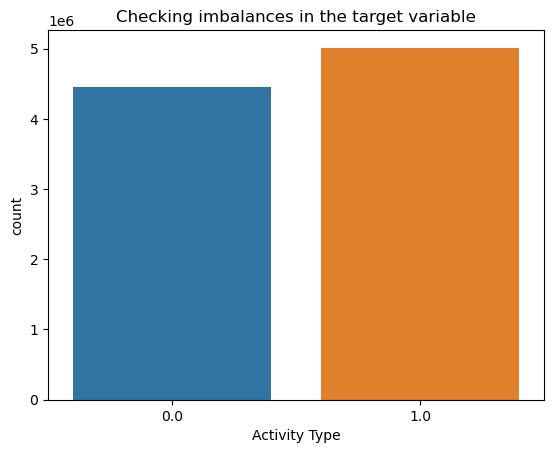

In [40]:
sns.countplot(x='Activity Type', data=df_f)
plt.title('Checking imbalances in the target variable')
plt.show()

In [38]:
df_f.to_csv('ScaledFallSimulation.csv', index=False)